## Exploring the Relationship Between Digital Adoption and Restaurant Performance

# Zomato Digital Adoption & Restaurant Performance Analysis

### Data Analyst Portfolio Project

**Objective:** Analyze how digital adoption, discounts, restaurant experience, city, cuisine and other business factors are associated with restaurant performance.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** 2,000-record synthetic Zomato-style restaurant dataset created for learning and business-analysis practice.

### Key analysis areas
- Digital adoption and revenue growth
- Order growth and restaurant performance
- Discount usage and performance segments
- Closure-risk patterns across cities
- Restaurant experience and performance
- Restaurant type and cuisine-level patterns

> **Note:** This is a synthetic learning dataset. The analysis identifies associations in the data and does not establish causal relationships.

## Analytical Approach

1. Loaded and inspected the dataset.
2. Checked data types, missing values and duplicate records.
3. Performed data cleaning and created analysis-ready features.
4. Created `Revenue_Change` to compare revenue before and after Zomato adoption.
5. Used descriptive statistics and visualizations to identify patterns.
6. Converted selected count-based comparisons into percentages where appropriate to avoid misleading conclusions caused by different group sizes.
7. Translated the findings into practical business recommendations.

## INTRODUCTION :

This project analyzes how digital adoption is associated with restaurant performance across cities, cuisines, restaurant types, revenue, ratings and business stability.
The goal is to identify relationships between digital adoption and restaurant performance, examine closure-risk patterns, and understand how discount usage differs across performance groups.

## BUSINESS PROBLEM STATEMENT:

The rapid growth of food-tech platforms like Zomato is transforming how restaurants reach customers.
Digital adoption is associated with differences in order growth and revenue in this dataset, while restaurants also show different levels of discount usage and closure risk.
Restaurant owners and platform managers often lack clear insights into how digital adoption affects restaurants across cities, cuisines and restaurant types.
This project aims to analyze restaurant data to understand how digital adoption is associated with business outcomes and support informed decision-making.

“Restaurants need data-driven insights to understand how digital adoption affects their growth and survival.”

## OBJECTIVE OF THE PROJECT:

The objective of this project is to perform Exploratory Data Analysis (EDA) to understand the relationship between digital adoption and restaurant performance in a Zomato-style dataset.
The analysis focuses on identifying key patterns and relationships to support better business decision-making.

## BUSINESS QUESTIONS
1. How is Digital_Adoption_Level associated with Performance_Status (Thriving, Stable, Struggling)?
2. How is Discount_Offered associated with Performance_Status across restaurants?
3. How does Orders_Change_% and Aggregate_Rating vary across Digital_Adoption_Level?
4. How does closure risk vary across cities and cuisines?
5. How do restaurant type and years in operation vary across digital adoption levels?
6. How does Revenue_Change vary across different digital adoption levels?

## DATA UNDERSTANDING:

**Data note:** this is a practice dataset of 2,000 Zomato-listed restaurants created for learning purposes, with the same structure as a real restaurant-performance dataset.
It can be replaced with any real Zomato dataset that has similar columns, and the same code will work after renaming the columns.

In [1]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("zomato_restaurant_impact.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Restaurant_ID           2000 non-null   object 
 1   Owner_Age               2000 non-null   int64  
 2   Owner_Gender            2000 non-null   object 
 3   City                    2000 non-null   object 
 4   Restaurant_Type         2000 non-null   object 
 5   Cuisine                 2000 non-null   object 
 6   Years_In_Operation      2000 non-null   int64  
 7   Digital_Adoption_Level  2000 non-null   object 
 8   Closure_Risk            2000 non-null   object 
 9   Discount_Offered        2000 non-null   object 
 10  Revenue_Before_Zomato   2000 non-null   int64  
 11  Revenue_After_Zomato    2000 non-null   int64  
 12  Performance_Status      2000 non-null   object 
 13  Staff_Count             2000 non-null   int64  
 14  Is_Chain                2000 non-null   

In [4]:
df.columns

Index(['Restaurant_ID', 'Owner_Age', 'Owner_Gender', 'City', 'Restaurant_Type',
       'Cuisine', 'Years_In_Operation', 'Digital_Adoption_Level',
       'Closure_Risk', 'Discount_Offered', 'Revenue_Before_Zomato',
       'Revenue_After_Zomato', 'Performance_Status', 'Staff_Count', 'Is_Chain',
       'Aggregate_Rating', 'Orders_Change_%'],
      dtype='object')

In [5]:
df.shape

(2000, 17)

In [6]:
df.head(10)

,Restaurant_ID,Owner_Age,Owner_Gender,City,Restaurant_Type,Cuisine,Years_In_Operation,Digital_Adoption_Level,Closure_Risk,Discount_Offered,Revenue_Before_Zomato,Revenue_After_Zomato,Performance_Status,Staff_Count,Is_Chain,Aggregate_Rating,Orders_Change_%
0,R0001,27,Male,Pune,Casual Dining,Biryani,1,High,Low,Yes,625800,707100,Stable,10,No,3.4,20.6
1,R0002,56,Male,Delhi NCR,Cafe,Desserts,6,Medium,High,No,225600,280000,Struggling,52,No,4.0,17.8
2,R0003,51,Male,Bengaluru,Fine Dining,North Indian,8,Medium,Medium,No,870200,1004700,Stable,29,Yes,4.0,8.7
3,R0004,42,Male,Chennai,Casual Dining,Street Food,2,Medium,Medium,No,464100,524400,Thriving,37,Yes,3.5,16.7
4,R0005,42,Male,Hyderabad,Casual Dining,Fast Food,3,High,Low,No,499400,538200,Thriving,45,No,3.5,34.3
5,R0006,60,Male,Chennai,Quick Bites,Fast Food,9,Low,High,No,363800,390900,Struggling,11,No,4.6,-4.0
6,R0007,27,Female,Delhi NCR,Fine Dining,South Indian,8,Medium,Low,Yes,607300,696100,Thriving,58,No,5.0,9.4
7,R0008,53,Male,Hyderabad,Cafe,Fast Food,6,High,Low,Yes,271200,282800,Thriving,27,No,4.3,34.7
8,R0009,32,Female,Hyderabad,Fine Dining,North Indian,6,Medium,Low,No,801100,797700,Thriving,53,No,4.5,14.9
9,R0010,27,Male,Chennai,Quick Bites,Street Food,2,Low,Medium,No,311800,324700,Struggling,26,No,4.5,14.2


categorical data are:

restaurant_id, owner_gender, city, restaurant_type, cuisine, digital_adoption_level, closure_risk, discount_offered, performance_status, is_chain.

real numerical data are:

revenue_before_zomato, revenue_after_zomato, Orders_Change_%, aggregate_rating

discrete numerical data are:

Owner_Age, Years_In_Operation, Staff_Count

## WHY DIGITAL_ADOPTION_LEVEL IS THE KEY VARIABLE

I considered Digital_Adoption_Level as the central variable because it allows comparison of restaurant outcomes across Low, Medium, and High digital environments.

Using this variable helps analyze:

Performance status

Order growth

Closure risk

Revenue change

Discounts

Ratings

## DATA CLEANING:

In [7]:
# checking is there any null values present in the dataset
df.isnull().sum()

,0
Restaurant_ID,0
Owner_Age,0
Owner_Gender,0
City,0
Restaurant_Type,0
Cuisine,0
Years_In_Operation,0
Digital_Adoption_Level,0
Closure_Risk,0
Discount_Offered,0


OBSERVATION:

From the above results we can conclude that above data set is free from null values.

In [8]:
# checking whether the dataset is contains any duplicated values
df.duplicated().sum()

np.int64(0)

OBSERVATIONS:

from the above results we can conclude that the dataset is free from duplicates

In [9]:
df = df.drop(columns=[
    "Restaurant_ID",
    "Owner_Age",
    "Owner_Gender",
    "Staff_Count",
    "Is_Chain"
])

In [10]:
df.head()

,City,Restaurant_Type,Cuisine,Years_In_Operation,Digital_Adoption_Level,Closure_Risk,Discount_Offered,Revenue_Before_Zomato,Revenue_After_Zomato,Performance_Status,Aggregate_Rating,Orders_Change_%
0,Pune,Casual Dining,Biryani,1,High,Low,Yes,625800,707100,Stable,3.4,20.6
1,Delhi NCR,Cafe,Desserts,6,Medium,High,No,225600,280000,Struggling,4.0,17.8
2,Bengaluru,Fine Dining,North Indian,8,Medium,Medium,No,870200,1004700,Stable,4.0,8.7
3,Chennai,Casual Dining,Street Food,2,Medium,Medium,No,464100,524400,Thriving,3.5,16.7
4,Hyderabad,Casual Dining,Fast Food,3,High,Low,No,499400,538200,Thriving,3.5,34.3


Observation

Columns such as Restaurant_ID, Owner_Age, Owner_Gender, Staff_Count, and Is_Chain were removed because they were not directly relevant to the core digital adoption analysis.
This helped simplify the dataset and focus the analysis on variables related to digital adoption, closure risk, orders, revenue, and restaurant outcomes.

## From the above results we can conclude that the above dataset is a cleaned data.

## FEATURE ENGINEERING

In [11]:
df["Revenue_Change"] = df["Revenue_After_Zomato"] - df["Revenue_Before_Zomato"]

Revenue Change Feature:

To measure the difference between revenue before and after Zomato adoption, a new feature was created

This helps measure the revenue difference between the before-Zomato and after-Zomato values available in the dataset.

## DATA VISUALIZATION:

## 1.How is Digital_Adoption_Level associated with Performance_Status (Thriving, Stable, Struggling)?

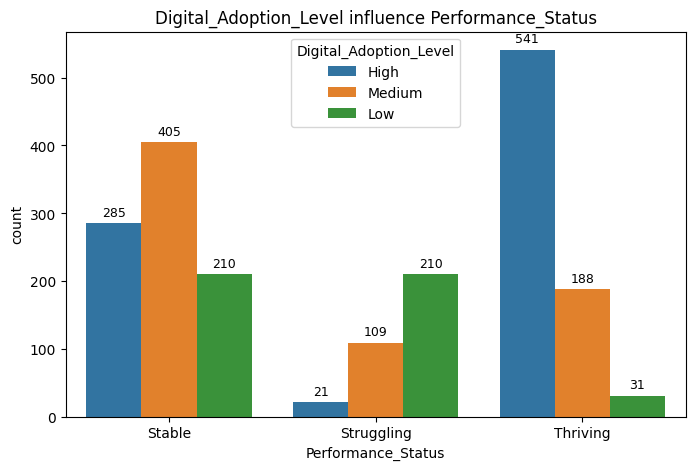

In [12]:
# Digital_Adoption_Level vs Performance_Status
plt.figure(figsize=(8,5))
ax=sns.countplot(hue="Digital_Adoption_Level",x="Performance_Status",data=df)
plt.title("Digital_Adoption_Level influence Performance_Status")
for container in ax.containers:
    ax.bar_label(container,
                 padding=3,
                 fontsize=9)
plt.show()

Observation:

High digital adoption has 541 thriving and 21 struggling restaurants. Low adoption has 31 thriving and 210 struggling restaurants, while Medium adoption has 405 stable restaurants. Because group sizes differ, the percentage view is more meaningful for comparison.

insights:

Digital adoption is strongly associated with performance status in this dataset. The struggling share is about 46.6% for Low adoption versus 2.5% for High adoption — roughly 19 times higher for the Low-adoption group. This is an observed association, not proof that digital adoption alone causes the difference.

## 2. How is Discount_Offered associated with Performance_Status across restaurants?

“Can offers and discounts help restaurants survive and grow on a food-delivery platform?”

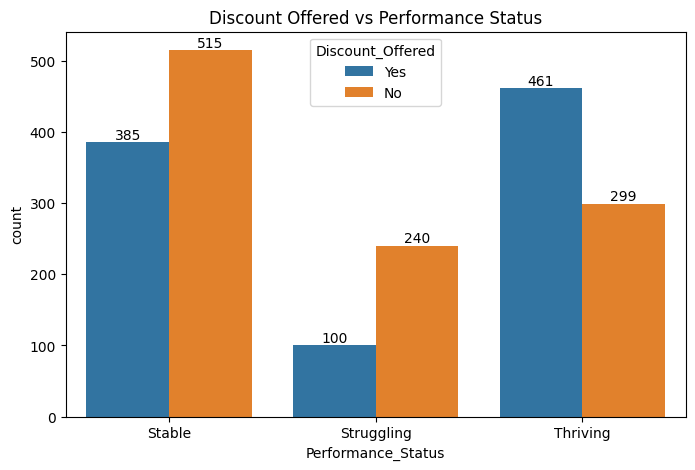

In [13]:
# Discount_Offered vs Performance_Status
plt.figure(figsize=(8,5))

ax = sns.countplot(
    hue='Discount_Offered',
    x='Performance_Status',
    data=df
)

plt.title('Discount Offered vs Performance Status')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation

Restaurants offering discounts have a lower struggling share (10.6%) than restaurants without discounts (22.8%), and a higher thriving share (48.7% vs 28.4%).
Stable restaurants are higher among those not offering discounts (515 vs 385).

Insight

Restaurants offering discounts show a higher proportion of thriving businesses and a lower proportion of struggling businesses in this dataset; this is an association, not proof of causation.

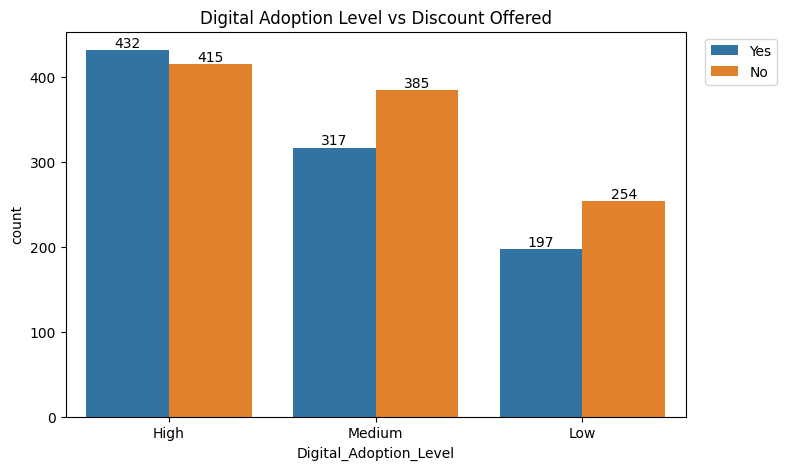

In [14]:
# Digital_Adoption_Level vs Discount Offered

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Digital_Adoption_Level',
    hue='Discount_Offered',
    data=df
)

plt.title('Digital Adoption Level vs Discount Offered')

for container in ax.containers:
    ax.bar_label(container)
plt.legend(bbox_to_anchor=(1.02,1),
        loc='upper left')
plt.show()

Observation

Low adoption restaurants offer discounts less often (197 yes vs 254 no), while High adoption restaurants are almost evenly split (432 yes vs 415 no).
Overall, discounts are used across all adoption levels.

Insight

Discount usage is highest in the High-adoption group (51.0%), compared with 45.2% for Medium and 43.7% for Low adoption. This shows an association between higher digital adoption and discount usage, but does not establish why the relationship exists.

Final Conclusion

> The analysis shows that discounts are associated with fewer struggling restaurants and more thriving ones, but digital adoption has the stronger effect on performance.
> Higher digital adoption restaurants also use discounts more often, highlighting that offers and digital presence work best together.

## 3. How does Orders_Change_% and Aggregate_Rating vary across Digital_Adoption_Level?

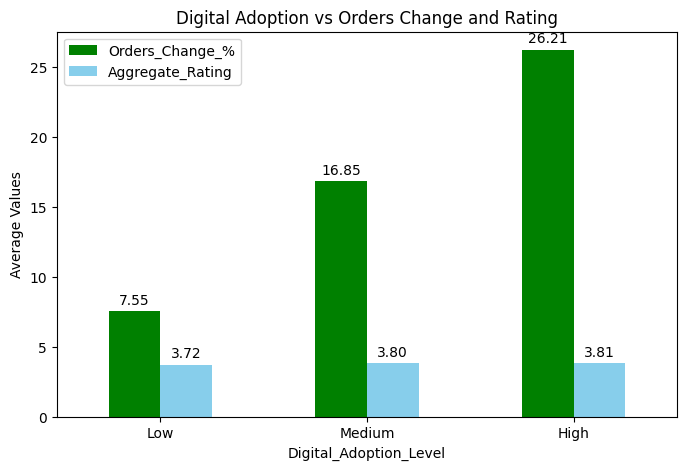

In [15]:
ax=df.groupby("Digital_Adoption_Level")[["Orders_Change_%","Aggregate_Rating"]].mean().loc[["Low","Medium","High"]].plot(
    kind="bar",figsize=(8,5),color=["green","skyblue"])
plt.ylabel("Average Values")
plt.title("Digital Adoption vs Orders Change and Rating")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.xticks(rotation=0)
plt.show()

Observation

Average order growth rises sharply with digital adoption, from 7.55% (Low) to 16.85% (Medium) to 26.21% (High), while the average rating stays almost flat (3.72 to 3.81).

Insight

Higher digital adoption is associated with higher average order growth, while average ratings change only slightly across adoption levels. The dataset does not contain enough variables to determine what causes rating differences.

## 4.How does closure risk vary across cities and cuisines?

### Closure Risk by City — Percentage View

Raw counts can be misleading because cities may contain different numbers of restaurants. The percentage view below compares the share of restaurants in each closure-risk category within each city.

In [16]:
# Closure risk by city — percentage view
city_risk = pd.crosstab(
    df["City"],
    df["Closure_Risk"],
    normalize="index"
).mul(100).round(2)

display(city_risk)

city_risk["High_Risk_%"] = city_risk["High"]
city_risk.sort_values("High_Risk_%", ascending=False).head(10)


Closure_Risk,High,Low,Medium
City,,,
Bengaluru,21.09,43.13,35.78
Chennai,23.44,43.23,33.33
Delhi NCR,36.50,29.45,34.05
Hyderabad,20.93,43.90,35.17
Kolkata,12.70,55.56,31.75
Mumbai,29.11,31.33,39.56
Pune,30.11,36.56,33.33
Vijayawada,12.50,57.95,29.55


Closure_Risk,High,Low,Medium,High_Risk_%
City,,,,
Delhi NCR,36.50,29.45,34.05,36.50
Pune,30.11,36.56,33.33,30.11
Mumbai,29.11,31.33,39.56,29.11
Chennai,23.44,43.23,33.33,23.44
Bengaluru,21.09,43.13,35.78,21.09
Hyderabad,20.93,43.90,35.17,20.93
Kolkata,12.70,55.56,31.75,12.70
Vijayawada,12.50,57.95,29.55,12.50


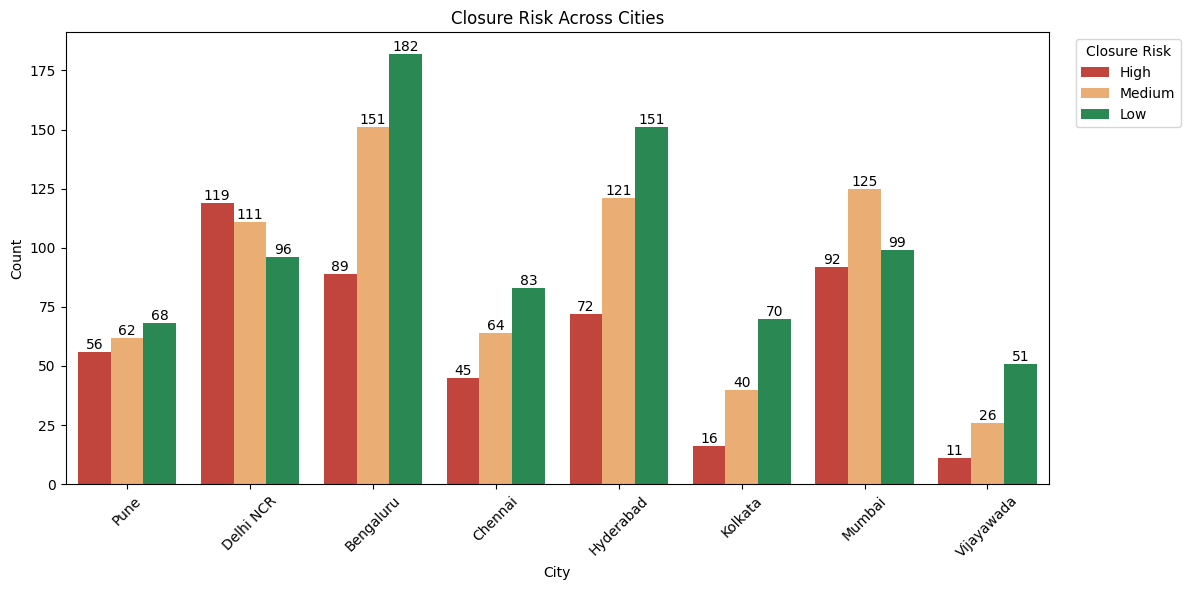

In [17]:
# Closure risk vs city
plt.figure(figsize=(12,6))

ax=sns.countplot(
    data=df,
    x="City",
    hue="Closure_Risk",
    hue_order=["High", "Medium", "Low"],
    palette=["#d73027", "#fdae61", "#1a9850"]
)

plt.title("Closure Risk Across Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.legend(
    title="Closure Risk",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

Observation

Delhi NCR (119) and Mumbai (92) have the highest counts of high closure risk, and Delhi NCR is the only city where high risk is the largest group.
Kolkata (70 low vs 16 high) and Vijayawada (51 low vs 11 high) show comparatively low closure risk.

Insight

Closure-risk percentages vary substantially by city. Delhi NCR has the highest high-risk share (36.5%), while Kolkata (12.7%) and Vijayawada (12.5%) have the lowest high-risk shares in this dataset. The dataset does not include rent or competition measures, so those factors should not be assumed to explain the difference.
The analysis indicates that restaurant outcomes vary across cities, but city-level differences should be interpreted alongside the number of restaurants in each city.

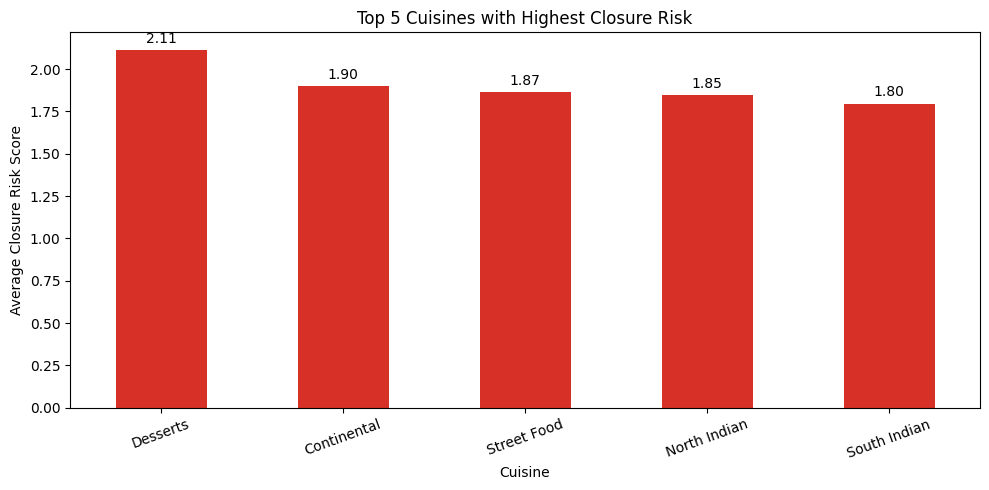

In [18]:
# Closure risk vs Cuisine

# Convert Closure Risk into numeric values
risk_map = {"Low":1, "Medium":2, "High":3}

df["Closure_Risk_Score"] = df["Closure_Risk"].map(risk_map)

# Top 5 cuisines with highest closure risk
top_cuisines = (
    df.groupby("Cuisine")["Closure_Risk_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,5))

ax = top_cuisines.plot(
    kind="bar",
    color="#d73027"
)

plt.title("Top 5 Cuisines with Highest Closure Risk")
plt.xlabel("Cuisine")
plt.ylabel("Average Closure Risk Score")
plt.xticks(rotation=20)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

Observation

Desserts has the highest closure risk score (2.11), followed by Continental (1.90) and Street Food (1.87).
North Indian and South Indian also appear in the top 5 but with much smaller gaps.

Insight

Desserts has the highest average closure-risk score (2.11), followed by Continental (1.90) and Street Food (1.87). This identifies a useful cuisine-level pattern for further investigation, but the dataset does not establish the reasons behind these differences.

## 5. How do restaurant type and years in operation vary across digital adoption levels?

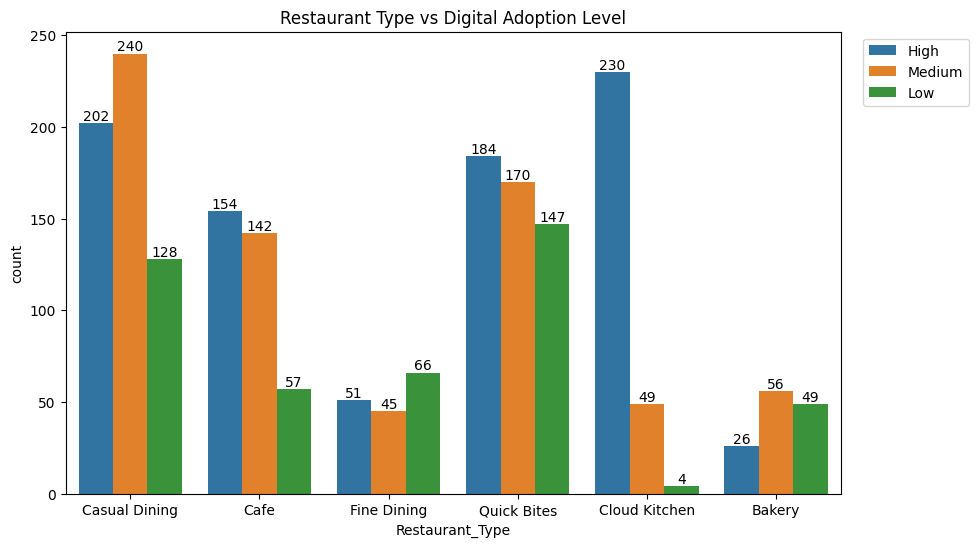

In [19]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Restaurant_Type',
    hue='Digital_Adoption_Level',
    data=df
)

plt.title('Restaurant Type vs Digital Adoption Level')

for container in ax.containers:
    ax.bar_label(container)
plt.legend(bbox_to_anchor=(1.02,1),
        loc='upper left')
plt.show()

Observation

Cloud Kitchens are almost entirely highly digital (230 High vs only 4 Low). Cafes and Casual Dining also lean towards High and Medium adoption.
Fine Dining and Bakeries have the highest share of Low adoption relative to their size.

Insight

The analysis shows clear differences in digital adoption by restaurant type. Cloud Kitchens are predominantly High adoption, while Fine Dining and Bakeries have larger Low-adoption shares. Restaurant type is therefore associated with digital adoption patterns in this dataset.

In [20]:
## Years in Operation vs Digital Adoption
df['Experience_Group'] = pd.cut(
    df['Years_In_Operation'],
    bins=[-1,2,5,10,25],
    labels=['0-2','3-5','6-10','11-25']
)

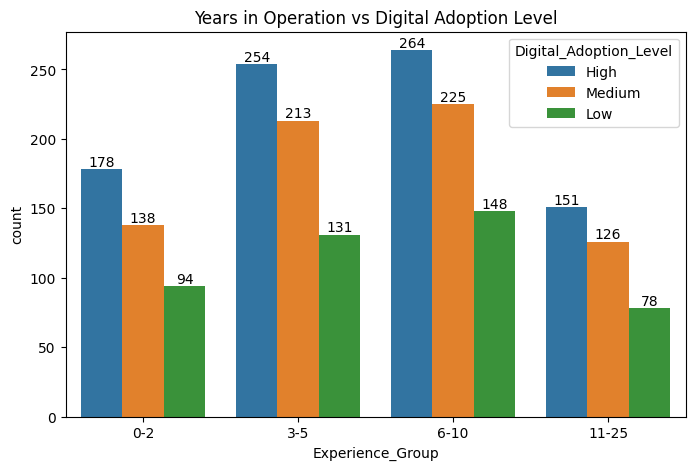

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Experience_Group',
    hue='Digital_Adoption_Level',
    data=df
)

plt.title('Years in Operation vs Digital Adoption Level')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation

Restaurants with 6-10 years of operation show the highest count of High digital adoption (264), but this group is also the largest.
In every group, roughly 41-43% of restaurants are at High adoption.

Insight

Digital adoption percentages are very similar across the experience groups: High adoption ranges from about 41.4% to 43.4%. This suggests that years in operation has only a small relationship with adoption level in this dataset. Restaurant type shows more visible differences.

## 6.How does revenue change across different digital adoption levels?

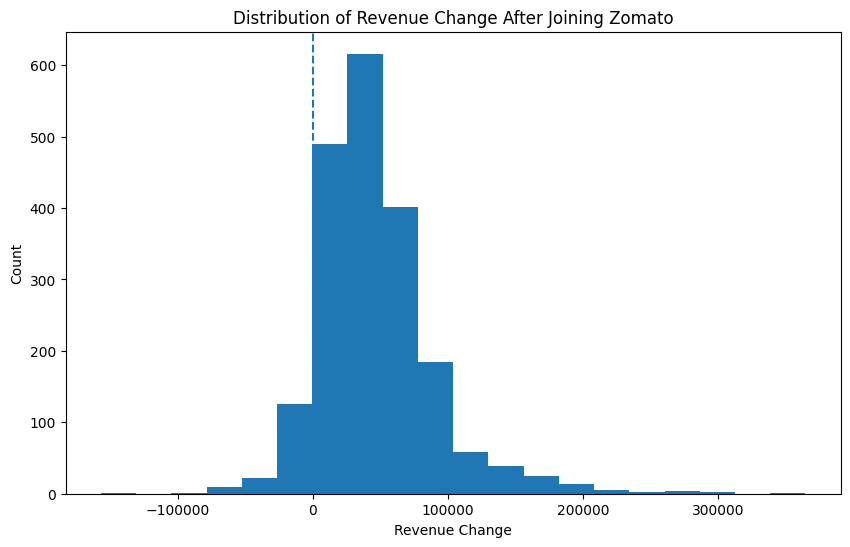

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df["Revenue_Change"], bins=20)

plt.title("Distribution of Revenue Change After Joining Zomato")
plt.xlabel("Revenue Change")
plt.ylabel("Count")

plt.axvline(0, linestyle="--")  # zero change reference line
plt.show()


Observation

The histogram shows the distribution of monthly revenue change after joining Zomato. About 91.6% of restaurants gained revenue, with an average gain of around ₹46,000.
The curve is right-skewed, meaning most restaurants saw modest gains while a few saw very large increases (above ₹3,00,000). The red dashed line at zero marks no change.

Insights

Majority of restaurants benefited from Zomato, as the distribution sits to the right of zero.

Revenue growth is uneven, with a small number of restaurants gaining much more than the rest.

Some restaurants lost revenue, possibly due to commissions, discounts or strong competition.

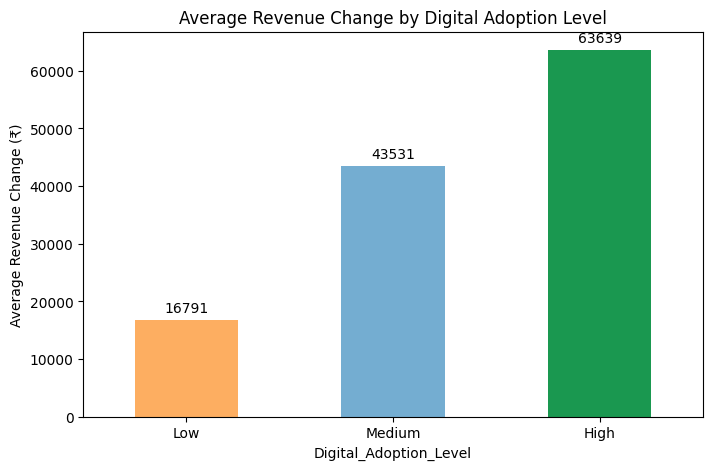

In [23]:
# Average revenue change by digital adoption level
plt.figure(figsize=(8,5))
ax = df.groupby("Digital_Adoption_Level")["Revenue_Change"].mean().loc[["Low","Medium","High"]].plot(
    kind="bar", color=["#fdae61","#74add1","#1a9850"])
plt.title("Average Revenue Change by Digital Adoption Level")
plt.ylabel("Average Revenue Change (₹)")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.show()

Observation

Average revenue change rises with digital adoption: about ₹16,800 for Low, ₹43,500 for Medium and ₹63,600 for High.

Insight

Average revenue change is about ₹63.6K for High adoption versus ₹16.8K for Low adoption — roughly 3.8 times higher. This indicates a strong association between adoption level and revenue change in this dataset, not a causal effect.

## Key Findings


> Higher digital adoption is strongly associated with better restaurant performance in this dataset, with high adoption restaurants mostly thriving and very few struggling.

> Higher digital adoption is associated with increased average order growth (26.21% for High vs 7.55% for Low) and higher average revenue change, while average ratings differ only slightly.

> Closure risk is higher in metro cities like Delhi NCR and Mumbai and in niche cuisines such as Desserts and Continental.

> Delivery-focused formats like Cloud Kitchens adopt digital tools the most, while Fine Dining adopts the least.

> Restaurants offering discounts are less often struggling and more often thriving.

## Business Insights
>Higher digital adoption is associated with stronger order and revenue outcomes in this dataset, while Low-adoption restaurants have a much higher struggling share.

>Discount usage is associated with different performance distributions, and the highest-adoption group also has slightly higher discount usage. Further analysis would be needed to determine whether combining both strategies produces better results.

>Closure-risk patterns vary across cities and cuisines, indicating that location and cuisine are useful dimensions for further risk analysis.

>Platforms could consider targeted digital onboarding for restaurant types with larger Low-adoption shares, such as Fine Dining and Bakeries.

>Average ratings vary only slightly across digital-adoption levels in this dataset, so order growth and customer rating appear to be different dimensions of restaurant performance.

## Problems Faced
>Handling multiple categorical variables (City, Cuisine, Restaurant Type) made visualization complex.

>Choosing the right plots to represent both numerical and categorical relationships was challenging.

>Interpreting closure risk across multiple dimensions required careful grouping.

>Ensuring clarity while avoiding overloaded graphs was difficult.

## How I Solved Them
>Reduced complexity by using grouped and summarized visualizations (Top 5 analysis, averages).

>Used different plot types (countplot, barplot, histplot) based on data type.

>Focused only on key business questions instead of plotting every variable.

>Simplified analysis by breaking large questions into smaller sub-questions.

## What I Learned
>Digital adoption significantly reshapes restaurant performance and growth.

>Data visualization is more effective when focused on business questions rather than all variables.

>Interpreting data is more important than just plotting graphs.

>Restaurant success depends on digital presence, location, cuisine and business model.

## Improvements
>We can use more advanced models to predict restaurant closure risk more accurately.

>If time-based data is available, we can analyze how the relationship with Zomato changes month by month.

>We can improve feature engineering to get deeper insights into revenue, commission and discount trends.

>We can use tools like Power BI or Tableau to create interactive dashboards for better visualization and storytelling.

# Portfolio Summary

### Key Takeaways
- Higher digital adoption is associated with stronger revenue growth and order growth in this dataset.
- Discount usage is associated with differences in restaurant performance segments, although the analysis does not prove that discounts cause better performance.
- Restaurant performance and closure-risk patterns vary across cities and should be evaluated using percentages as well as absolute counts.
- Restaurant experience and business characteristics provide additional context for understanding performance differences.

### Business Recommendations
1. Encourage low-adoption restaurants to strengthen their digital presence and online ordering capabilities.
2. Evaluate discount strategies using both revenue growth and profitability rather than discount usage alone.
3. Prioritize city-level strategies using risk percentages instead of raw restaurant counts.
4. Use restaurant experience and other operational factors together when identifying restaurants that may need support.

### Important Limitation
This project uses a synthetic learning dataset. Findings describe relationships observed in this dataset and should not be interpreted as official Zomato statistics or causal business effects.